(Planned)

Figure 1. Conceptual Diagram of an IMAS/IDS-based Integrated Workflow (CH 1)

Figure 2. Overall Architecture of the VEST Integrated Platform (CH 2)

Figure 3. VEST 2D Poloidal Geometry for Electromagnetic Modeling (CH 3)

<repo>/vaft/omas/__init__.py:111: RuntimeWarning: Could not infer an IMAS DD version for omas_json; using 3.41.0


<repo>/vaft/omas/process_wrapper.py:437: RuntimeWarning: VEST_em_coupling_pf_versions.npz: mutual_passive_passive violates reciprocity by 0.00127 (max |M - M^T| / max |M|); symmetrized to (M + M^T)/2 on load. See issue #347.


(<Figure size 600x700 with 2 Axes>,
 <Axes: title={'center': 'Vacuum psi at t = 306.3 ms'}, xlabel='R [m]', ylabel='Z [m]'>)

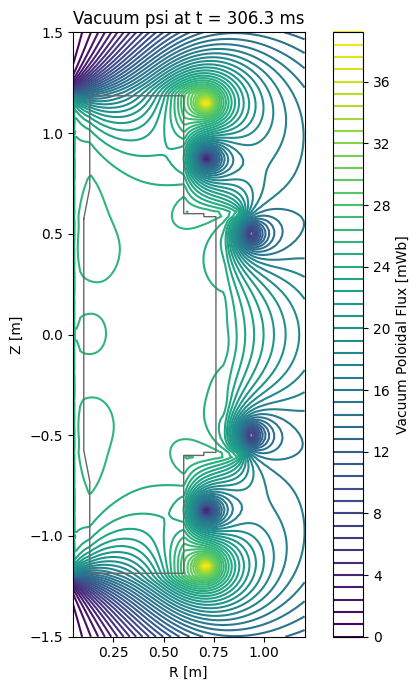

In [ ]:
import vaft
sample_path = vaft.data.sample(39915, representation="omas")
ods = vaft.omas.load(sample_path)
vaft.omas.plot_equilibrium_field_psi_vacuum(ods)

In [ ]:
from omas import *
import vaft
import matplotlib.pyplot as plt


# matplotlib 설정 개선
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20


# ods = vaft.omas.load(vaft.data.sample(39915, representation="omas"))
# vaft.omas.plot_equilibrium_field_psi_vacuum(ods)

PastedGraphic-1.png

Figure 4. Equilibrium Refinement using CHEASE

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import vaft
from vaft.data import read_geqdsk
from vaft.data.resources import data_path
from vaft.process.equilibrium import as_equilibrium, derive_global_descriptors

# Shot 48224 at 300 ms, packaged with VAFT three ways: the magnetic EFIT
# reconstruction, its CHEASE refinement on a 513x513 grid, and the kinetic-EFIT
# variant fitted with the Thomson profiles. Same shot, same instant, so the
# comparison is of the reconstructions rather than of discharges.
SHOT, TIME_MS = 48224, 300
equilibria = {
    "EFIT": data_path(f"kineticEfit/g0{SHOT}.00{TIME_MS}"),
    "CHEASE": data_path(f"kineticEfit/g0{SHOT}.00{TIME_MS}.chease"),
    "kinetic EFIT": data_path(f"kineticEfit/g0{SHOT}.00{TIME_MS}.kinetic_efit"),
}

geqdsk = {label: read_geqdsk(path) for label, path in equilibria.items()}
ods_by_label = {label: item.to_omas() for label, item in geqdsk.items()}
descriptors = {
    label: derive_global_descriptors(as_equilibrium(item))
    for label, item in geqdsk.items()
}

print(f"{'':14s} {'grid':>9s} {'Ip [kA]':>9s} {'R0 [m]':>8s} {'a [m]':>7s} "
      f"{'kappa':>7s} {'q95':>7s}  COCOS")
for label, item in geqdsk.items():
    values = descriptors[label]
    convention = as_equilibrium(item).convention
    print(f"{label:14s} {item['NW']:4d}x{item['NH']:<4d} "
          f"{item['CURRENT']/1e3:9.1f} {values['major_radius'].value:8.4f} "
          f"{values['minor_radius'].value:7.4f} {values['elongation'].value:7.4f} "
          f"{values['q95'].value:7.3f}  {convention.identified}")

<repo>/vaft/data/eqdsk.py:985: RuntimeWarning: q on axis is 8.07, 4.2x above its immediate neighbours (median 1.9); the toroidal flux integral carries that into rho_tor_norm. The profile is used as given -- see issue #317.


                    grid   Ip [kA]   R0 [m]   a [m]   kappa     q95  COCOS
EFIT            129x129      143.2   0.3920  0.2880  1.7448   5.827  (1, 2)
CHEASE          513x513     -137.7   0.3922  0.2860  1.7430   5.835  (7, 8)
kinetic EFIT    129x129      143.2   0.3916  0.2876  1.7461   5.818  (1, 2)


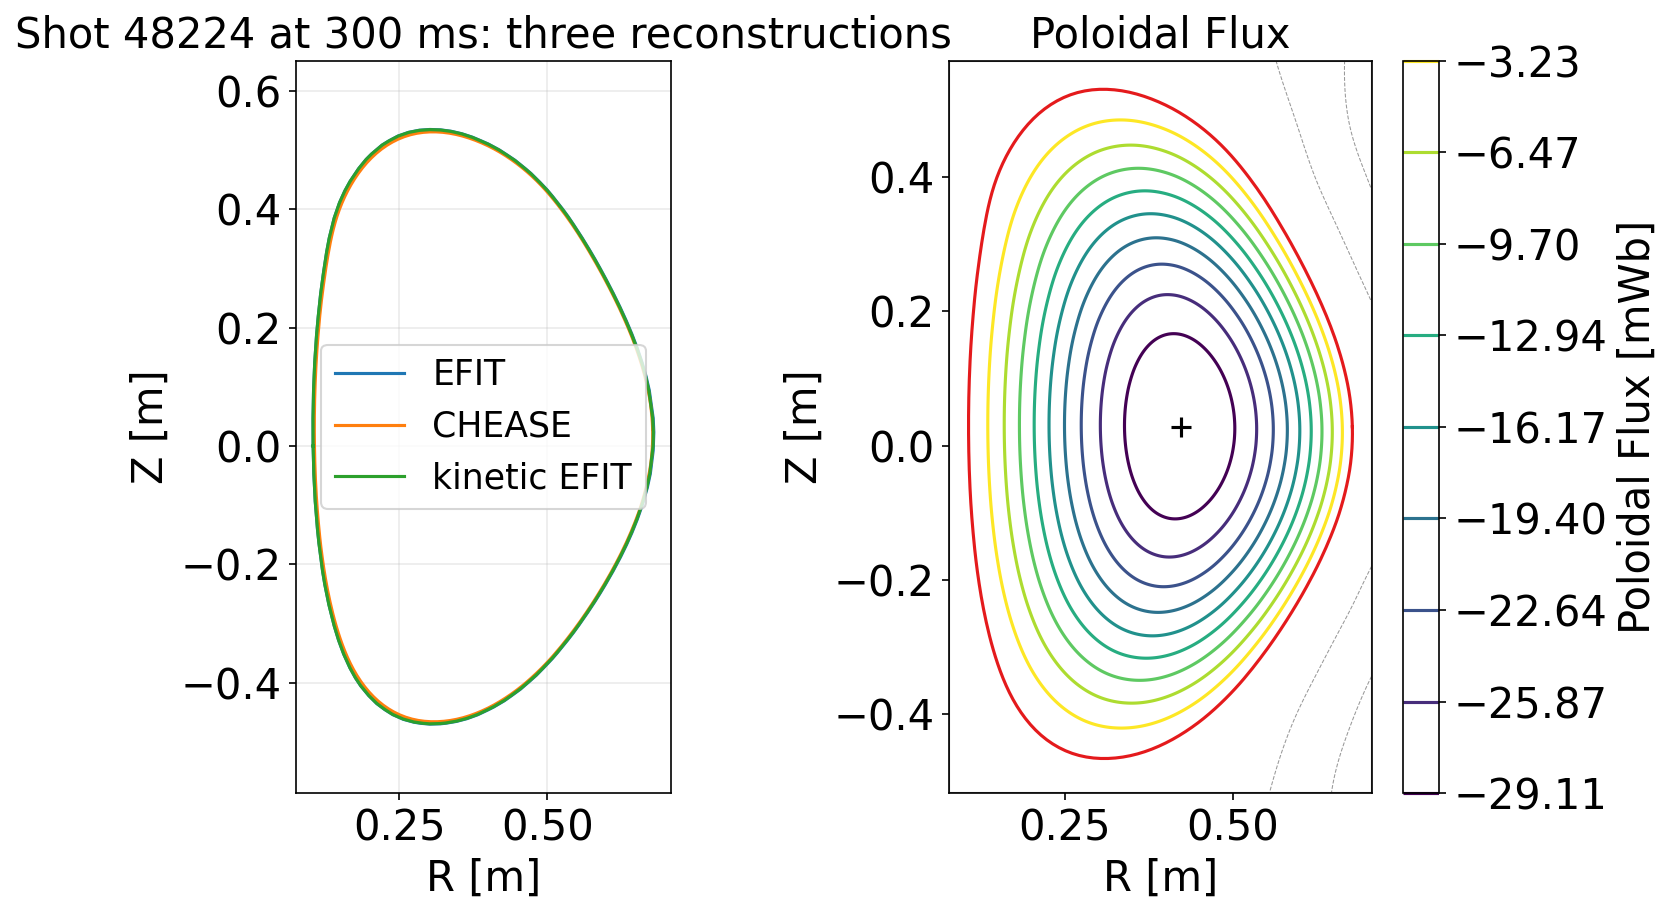

stored sgn(Ip): {'EFIT': 1, 'CHEASE': -1, 'kinetic EFIT': 1}


In [ ]:
# The boundary overlay comes from the canonical renderer, which draws every
# entry it is given; the wall and the flux map are its own layers. The three
# local helpers this cell used to define -- a wall plotter, a flux-contour
# plotter and a two-ODS comparison -- are all this call now (#64).
fig, (ax_boundary, ax_psi) = plt.subplots(1, 2, figsize=(11, 6.5))

vaft.omas.plot_equilibrium_geometry_boundary(
    list(ods_by_label.values()), label=list(ods_by_label), ax=ax_boundary,
)
ax_boundary.set_title(f"Shot {SHOT} at {TIME_MS} ms: three reconstructions")

vaft.omas.plot_equilibrium_field_psi(
    ods_by_label["CHEASE"], label=["CHEASE"], ax=ax_psi,
)
fig.tight_layout()
plt.show()

# The CHEASE refinement stores the opposite plasma-current sign from the EFIT it
# refines -- a COCOS difference, not a different equilibrium. The descriptors
# above carry each file's identified convention beside its numbers.
signs = {label: int(np.sign(item["CURRENT"])) for label, item in geqdsk.items()}
print("stored sgn(Ip):", signs)

Figure 5. Kinetic Profile Reconstruction Process

Figure 6. Comprehensive Analysis of a Representative Discharge (e.g., Shot #41660)

In [ ]:
print('Skipped external VEST_tools / /srv ODS merge section: required files are not available in this environment.')
# The downstream cells work from the packaged EFIT reconstruction instead.
ods = ods_by_label["EFIT"].copy()

Skipped external VEST_tools / /srv ODS merge section: required files are not available in this environment.


Skipped external diagnostics/eddy/CHEASE ODS update section; using local GEQDSK-derived ODS instead.


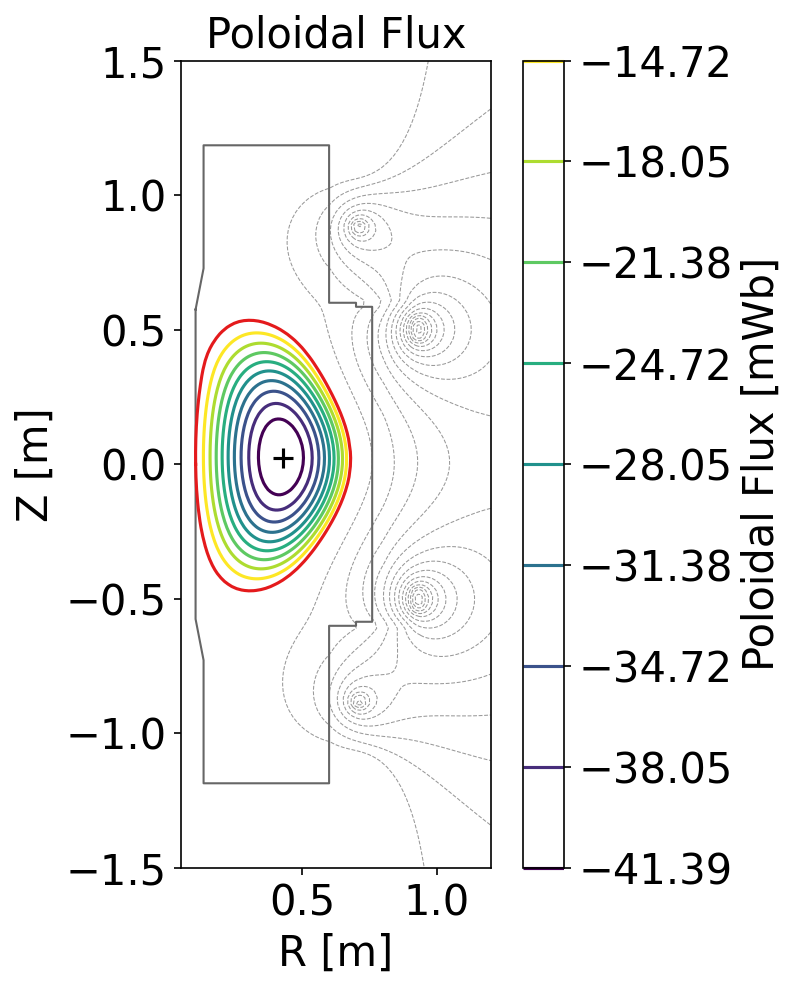

In [ ]:
print('Skipped external diagnostics/eddy/CHEASE ODS update section; using local GEQDSK-derived ODS instead.')
vaft.omas.plot_equilibrium_field_psi(ods)
plt.show()


Figure 7. Statistical Distribution of Key Operational Parameters

In [ ]:
print('Skipped external omas_history_new.xlsx publication scatter section: source Excel file is not available in this environment.')


Skipped external omas_history_new.xlsx publication scatter section: source Excel file is not available in this environment.


Figure 8. Statistical Analysis of VEST Operational Space

In [ ]:
print('Skipped external chease_stability_history.xlsx load section: source Excel file is not available in this environment.')


Skipped external chease_stability_history.xlsx load section: source Excel file is not available in this environment.


In [ ]:
print('Skipped detailed stability-limit plotting demo: external stability dataframe is not available in this environment.')


Skipped detailed stability-limit plotting demo: external stability dataframe is not available in this environment.


In [ ]:
print('Skipped alternate stability-limit plotting demo: external stability dataframe is not available in this environment.')


Skipped alternate stability-limit plotting demo: external stability dataframe is not available in this environment.


In [ ]:
import pandas as pd

# (The delta-prime grid helper lived here; see the note below.)

In [ ]:
print('Skipped stability-limit delta-prime grid calls: external input_file is not available in this environment.')


Skipped stability-limit delta-prime grid calls: external input_file is not available in this environment.


In [ ]:
# The pairwise-scatter and delta-prime-grid figures of this section were drawn by
# notebook-local helpers reading `chease_dcon_history.xlsx`, which is not part of
# this repository. The helpers are removed rather than left defined and never
# called (#64): what they need is the stability history, and what should draw
# them once it exists is a renderer in vaft.plot, not a cell here.
print("Stability-history figures need chease_dcon_history.xlsx; not in this repository.")

Stability-history figures need chease_dcon_history.xlsx; not in this repository.


Figure 9. Correlation of an Observed Instability with Stability Analysis 


In [ ]:
from omas import ODS

import numpy as np
import matplotlib.pyplot as plt

import vaft
from vaft.data.resources import data_path
from vaft.machine_mapping.magnetics import magnetics
from vaft.process.fluctuation import compute_spectrogram
from vaft.process.signal_processing import fir_filter

# The raw archive packaged with VAFT, so this figure is reproducible without the
# VEST raw database: shot 45531, mapped through the same magnetics path the
# fluctuation analysis uses.
FLUCTUATION_SHOT = 45531
fixture = data_path("legacy/shot_45531.json.gz")
raw_template = str(fixture.parent / "shot_{shot}.json.gz")

fluctuation_ods = ODS()
magnetics(
    fluctuation_ods, shot=FLUCTUATION_SHOT,
    tstart=0.26, tend=0.36, dt=4e-5, raw_source=raw_template,
)
print(f"shot {FLUCTUATION_SHOT}: {len(fluctuation_ods['magnetics.b_field_pol_probe'])} probes mapped")

Field 207 not found in JSON. Skipping...


No valid fields loaded from JSON for shot=45531.


Field 241 not found in JSON. Skipping...


No valid fields loaded from JSON for shot=45531.


Field 209 not found in JSON. Skipping...


...

Field 217 not found in JSON. Skipping...


No valid fields loaded from JSON for shot=45531.


Field 218 not found in JSON. Skipping...


No valid fields loaded from JSON for shot=45531.


shot 45531: 98 probes mapped


In [ ]:
# One Mirnov channel, band-limited with the library's linear-phase filter before
# the transform: a phase-preserving filter is what a mode-number reading needs,
# and vaft.process.signal_processing.fir_filter is where that design now lives.
# Channels are chosen by carrying data, not by position -- the equilibrium
# Mirnovs share the array with the fast fluctuation ones and store no voltage.
# The fast Mirnovs share the probe array with the equilibrium ones, which carry
# no voltage at all, so select by name *and* by carrying samples.
probe_name = None
for index in range(len(fluctuation_ods["magnetics.b_field_pol_probe"])):
    name = str(fluctuation_ods[f"magnetics.b_field_pol_probe.{index}.name"])
    samples = fluctuation_ods.get(
        f"magnetics.b_field_pol_probe.{index}.voltage.data", None
    )
    if name.startswith("OutMirnov") and samples is not None and np.size(samples) > 1000:
        probe, probe_name = index, name
        break
if probe_name is None:
    raise RuntimeError("no fast Mirnov channel with voltage samples in this archive")

base = f"magnetics.b_field_pol_probe.{probe}.voltage"
time = np.asarray(fluctuation_ods[f"{base}.time"], dtype=float)
voltage = np.asarray(fluctuation_ods[f"{base}.data"], dtype=float)
rate = 1.0 / np.median(np.diff(time))

band_limited = fir_filter(voltage, (2.0e3, 1.0e5), rate, kind="bandpass")
spectrogram = compute_spectrogram(time, band_limited, nperseg=2048)
print(f"{probe_name}: {time.size} samples at {rate/1e6:.2f} MS/s -> "
      f"{spectrogram.frequency.size} frequencies x {spectrogram.time.size} bins")

OutMirnov_45_L1-01: 199999 samples at 2.00 MS/s -> 1025 frequencies x 194 bins


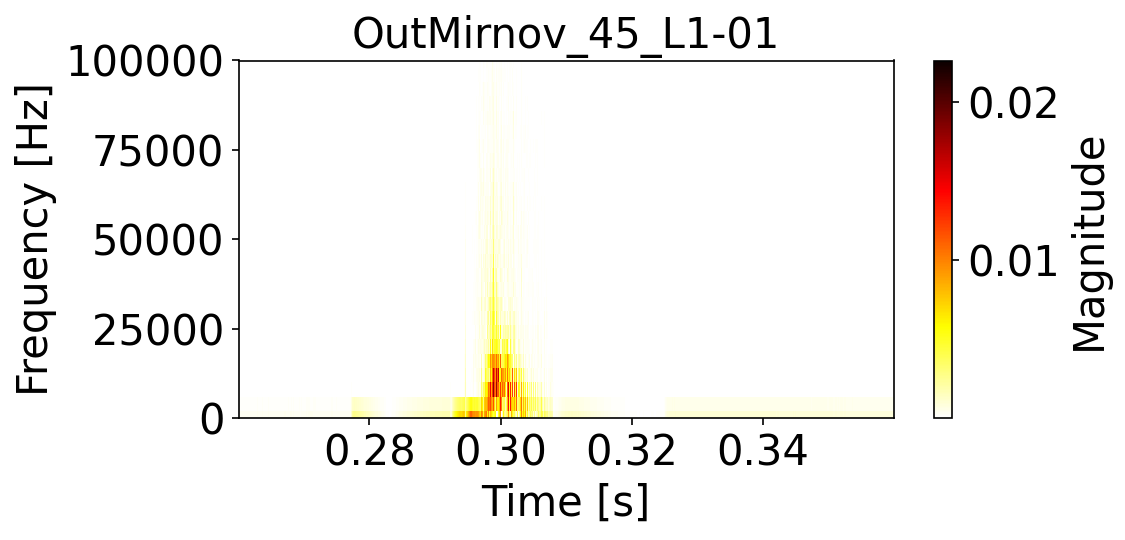

(<Figure size 1200x600 with 2 Axes>,
 <Axes: title={'center': 'OutMirnov_45_L1-01'}, xlabel='Time [s]', ylabel='Frequency [Hz]'>)

In [ ]:
# The canonical renderer over the same ODS and the same channel: no local
# pcolormesh, no local colour-limit handling, and the title comes from the data.
# A spectrogram is a single-channel view, so it takes `channel=` rather than the
# `selection=` vocabulary the multi-channel plots use.
vaft.omas.plot_mirnov_spectrogram(
    fluctuation_ods, channel=probe, max_frequency=1.0e5, show=True
)

In [ ]:
print('Skipped operation-stability analysis function/call: external /srv ODS, raw DB, and Excel inputs are not available in this environment.')


Skipped operation-stability analysis function/call: external /srv ODS, raw DB, and Excel inputs are not available in this environment.


In [ ]:
print('Skipped unstable-shot mining: external chease_dcon_history.xlsx is not available in this environment.')
ideal_unstable_shots = []
n1_resistive_unstable_shots = []
n2_resistive_unstable_shots = []


Skipped unstable-shot mining: external chease_dcon_history.xlsx is not available in this environment.


In [ ]:
# The vacuum-field panel here used to plot arrays of zeros standing in for a
# calculation that could not run, which reads as a result and is not one. The
# real calculation is offline and lives in
# `eddy_current_calculation_and_startup_analysis.ipynb`, which solves the
# passive-circuit response and checks the field it produces against the flux
# loops before reading anything off it.
print("Vacuum-field figure: see eddy_current_calculation_and_startup_analysis.ipynb")

Vacuum-field figure: see eddy_current_calculation_and_startup_analysis.ipynb


In [ ]:
print('Skipped batch operation-stability figure export: external Excel/ODS inputs are not available in this environment.')


Skipped batch operation-stability figure export: external Excel/ODS inputs are not available in this environment.


In [ ]:
print('Skipped external VFIT_tools-based operation analysis helper definitions in this environment.')


Skipped external VFIT_tools-based operation analysis helper definitions in this environment.
